<small>This repository was made by [Riccardo Campi](https://scholar.google.com/citations?user=JWSoz7EAAAAJ&hl=it), PhD student in AI & DS @ Politecnico di Milano, DEIB, Data Science Lab.</small>
<br><small>Thanks to [Madhura Patil](https://www.kaggle.com/madhuradp8825) for inspiring this notebook.</small>

## Library Imports and CSV Loading

In this section, we import the necessary libraries for data analysis and visualization, then load the `Stroke Prediction Dataset` from a CSV file.

In [19]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('./datasets/healthcare-dataset-stroke-data.csv')

## 2. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is an approach to analyzing datasets to summarize their main characteristics, often with visual methods.
<br>It helps us understand the data better and identify patterns, outliers, and relationships.

EDA can be categorized into three main types:
1. **Univariate Analysis**: This involves analyzing a single variable at a time. It helps in understanding the distribution of that variable.
2. **Bivariate Analysis**: This involves analyzing two variables to understand the relationship between them.
3. **Multivariate Analysis**: This involves analyzing multiple variables simultaneously to understand the complex relationships among them.

### 2.1 Univariate Analysis

**Univariate analysis** involves analyzing a **single variable at a time**.
<br>It helps in understanding the distribution of that variable.

#### 2.1.1 Summary Statistics for Numerical Variables

We can use **summary statistics** to understand the properties of the data:
- **Mean**: The average value of a numerical variable.
- **Mode**: The most frequent value of a variable.
- **Median**: The middle value of a numerical variable when sorted.
- **Percentiles**: Values that divide the data into 100 equal parts, such as the 25th percentile (Q1), 50th percentile (median), and 75th percentile (Q3).
- **Range**: The difference between the maximum and minimum values of a numerical variable.
- **Standard Deviation**: A measure of the amount of variation in a numerical variable.
- **Interquartile Range (IQR)**: The range between the first quartile (Q1) and the third quartile (Q3) of a numerical variable.
- **Median Absolute Deviation (MAD)**: A robust measure of variability that is less sensitive to outliers than standard deviation.

**Mean and Standard Deviation**

The **mean** provides the average value of a numerical variable, while the **standard deviation** measures the amount of variation in the data.

In [20]:
# Compute mean and std age by stroke status
mean_age_by_stroke = data.groupby('stroke')['age'].mean().reset_index()
std_age_by_stroke = data.groupby('stroke')['age'].std().reset_index()

# Print the mean and std age by stroke status
print(mean_age_by_stroke, "\n")
print(std_age_by_stroke)

   stroke        age
0       0  41.971545
1       1  67.728193 

   stroke        age
0       0  22.291940
1       1  12.727419


**Mode**

The **mode** is the most frequent value of a variable. It can be useful for understanding the most common category in a categorical variable or the most common value in a numerical variable.

In [21]:
#Compute mode age by stroke status
mode_age_by_stroke = data.groupby('stroke')['age'].agg(lambda x: x.mode()[0]).reset_index()

# Print the mode age by stroke status
print(mode_age_by_stroke)

   stroke   age
0       0  52.0
1       1  78.0


**Percentiles (Q1, Median, Q3)**

**Percentiles** divide the data into 100 equal parts.

- The **25th percentile (Q1)** represents the value below which 25% of the data falls
- The **50th percentile (median)** represents the value below which 50% of the data falls
- The **75th percentile (Q3)** represents the value below which 75% of the data falls

In [22]:
# Compute the 25th (Q1), 50th (Median), and 75th (Q3) percentiles of age by stroke status
percentiles_age_by_stroke = data.groupby('stroke')['age'].quantile([0.25, 0.5, 0.75]).unstack().reset_index()    
# Print the percentiles of age by stroke status
print(percentiles_age_by_stroke)

   stroke  0.25   0.5  0.75
0       0  24.0  43.0  59.0
1       1  59.0  71.0  78.0


**Range and Interquartile Range (IQR)**

The **range** is the difference between the maximum and minimum values of a numerical variable, while the **interquartile range (IQR)** is the range between the first quartile (Q1) and the third quartile (Q3) of a numerical variable.

In [23]:
# Compute range and IQR of age by stroke status
range_age_by_stroke = data.groupby('stroke')['age'].agg(lambda x: x.max() - x.min()).reset_index(name='range')
iqr_age_by_stroke = data.groupby('stroke')['age'].agg(lambda x: x.quantile(0.75) - x.quantile(0.25)).reset_index(name='IQR')

# Print the range and IQR of age by stroke status
print(range_age_by_stroke, "\n")
print(iqr_age_by_stroke)

   stroke  range
0       0  81.92
1       1  80.68 

   stroke   IQR
0       0  35.0
1       1  19.0


**Median Absolute Deviation (MAD)**

The **median absolute deviation (MAD)** is a robust measure of variability that is less sensitive to outliers than standard deviation. It is calculated as the median of the absolute deviations from the median of the data.

In [24]:
# Compute the median absolute deviation (MAD) of age by stroke status
mad_age_by_stroke = data.groupby('stroke')['age'].agg(lambda x: np.median(np.abs(x - np.median(x)))).reset_index(name='MAD')
# Print the MAD of age by stroke status
print(mad_age_by_stroke)

   stroke   MAD
0       0  17.0
1       1   8.0


#### 2.1.2 Plots for Univariate Analysis

We can also use various plots to summarize the data (remember the Anscombe’s quartet):
- **Count Plots**: Used for categorical variables to show the frequency of each category.
- **Pie Charts**: Used for categorical variables to show the proportion of each category.
- **Histograms**: Used for numerical variables to show the distribution of the data.
- **Box Plots**: Used for numerical variables to show the distribution and identify outliers.
- **Violin Plots**: Used for numerical variables to show the distribution and density of the data.

##### 2.1.2.1 Count Plots (Categorical Variables)
To analyze categorical variables, we can use **count plots** to visualize the frequency of each category.
<br>For example, we can analyze the distribution of `stroke` occurrences, `gender`, or `work_type`.

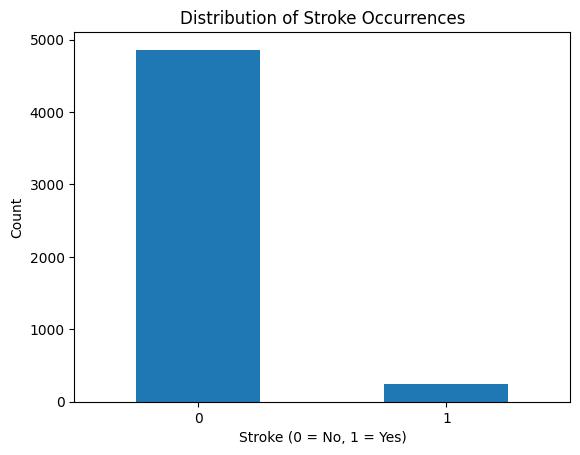

In [25]:
data['stroke'].value_counts().plot(kind='bar') # Plot the count of stroke occurrences
plt.title('Distribution of Stroke Occurrences')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

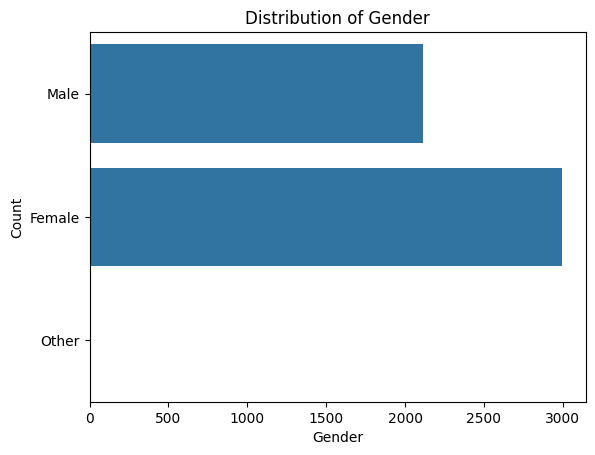

In [26]:
sns.countplot(data['gender']) # Plot the count of each gender
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

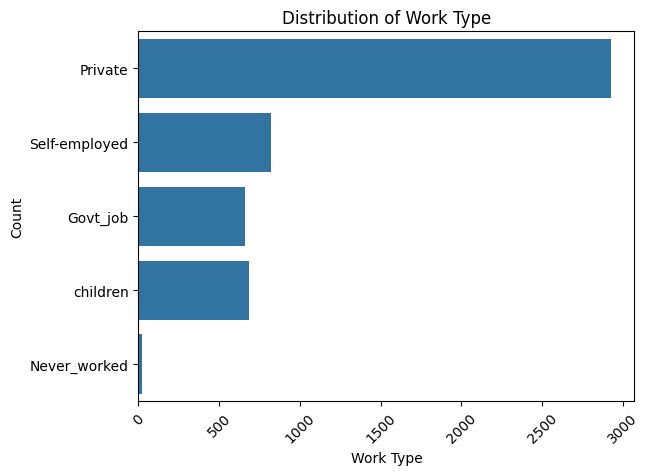

In [27]:
sns.countplot(data['work_type']) # Plot the count of each work type
plt.title('Distribution of Work Type')
plt.xlabel('Work Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

##### 2.1.2.2 Pie Charts (Categorical Variables)
**Pie charts** can also be used to visualize the proportion of each category in a categorical variable.
<br>For example, we can visualize the distribution of `smoking_status` or `ever_married` in the dataset.

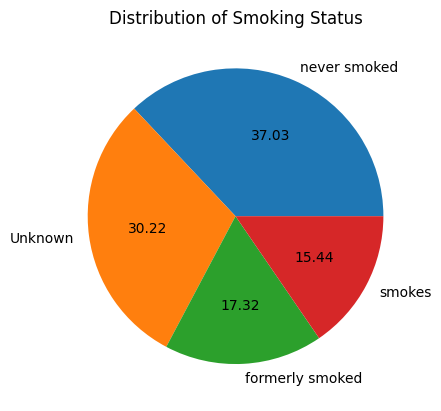

In [28]:
data['smoking_status'].value_counts().plot(kind='pie', autopct='%.2f') # Plot the distribution of smoking status
plt.title('Distribution of Smoking Status')
plt.ylabel('')
plt.show() 

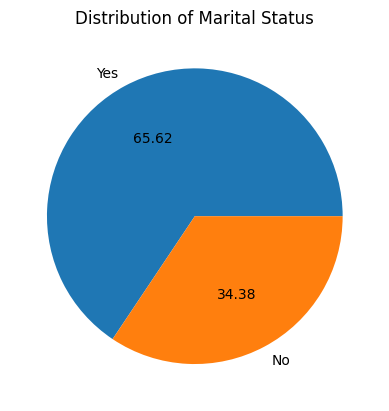

In [29]:
data['ever_married'].value_counts().plot(kind='pie', autopct='%.2f') # Plot the distribution of marital status
plt.title('Distribution of Marital Status')
plt.ylabel('')
plt.show()

##### 2.1.2.3 Histograms (Numerical Variables)

For numerical variables, we can use **histograms** to visualize the distribution of the data.
<br>Histograms show the frequency of data points within specified ranges (bins).
<br>This helps us understand the central tendency, spread, and shape of the distribution.

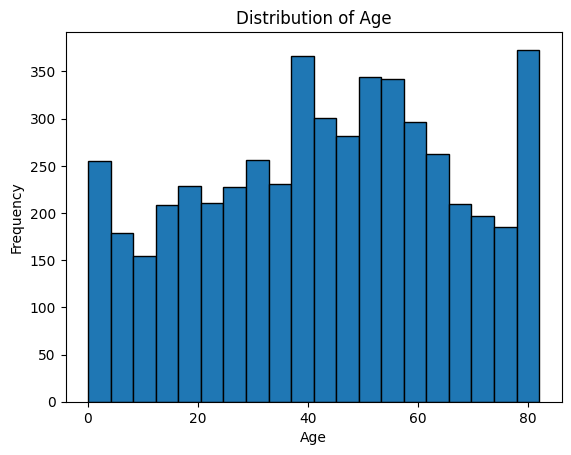

In [30]:
plt.hist(data['age'], bins=20, edgecolor='black') # Plot the histogram of age
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Changing the number of bins in the histogram can provide different insights into the data distribution.
<br>For example, using 10 bins may give a more general overview, while using 20 bins can reveal more detailed patterns in the data.

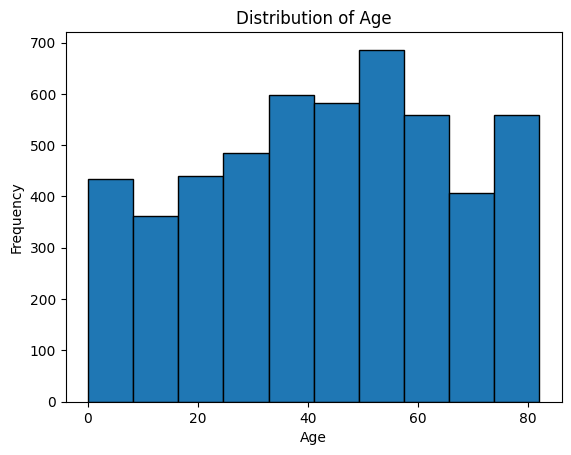

In [31]:
plt.hist(data['age'], bins=10, edgecolor='black') # Plot the histogram of age
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Using the seaborn `sns.displot()` function, we can see if there is **skewness** in the distribution of the data.

In [32]:
data['age'].skew() # Calculate the skewness of the age distribution

-0.1370593225984694

> `-0.0036722` means that the distribution of age is very close to being perfectly symmetrical, with a very slight left skew. In practical terms, this means that the ages in the dataset are fairly evenly distributed around the mean, with no significant outliers or extreme values pulling the distribution in either direction.

We can also create a histogram with a **kernel density estimate (KDE)** by setting `kde=True` to visualize the distribution of a numerical variable along with its density curve. This provides a more comprehensive view of the data distribution.

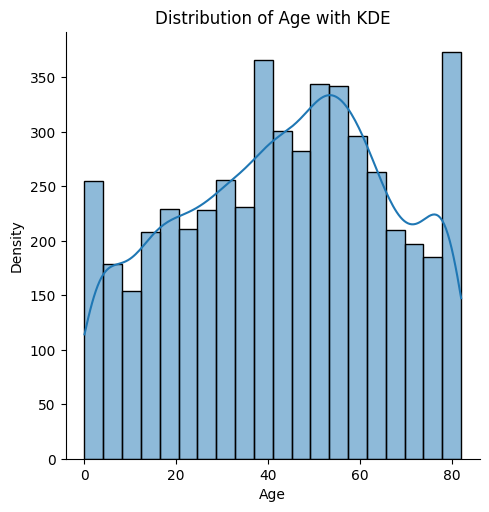

In [33]:
sns.displot(data['age'], kde=True) # Plot the distribution of age with a KDE curve
plt.title('Distribution of Age with KDE')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

##### 2.1.2.4 Box Plots (Numerical Variables)
**Box plots** are another useful tool for visualizing the distribution of numerical variables.
<br>They show the median, quartiles, and potential outliers in the data.
<br>This can help us identify any skewness or outliers in the distribution.

For example, we can create a box plot for the `avg_glucose_level` and `age` variables to analyze their distributions and identify any outliers.

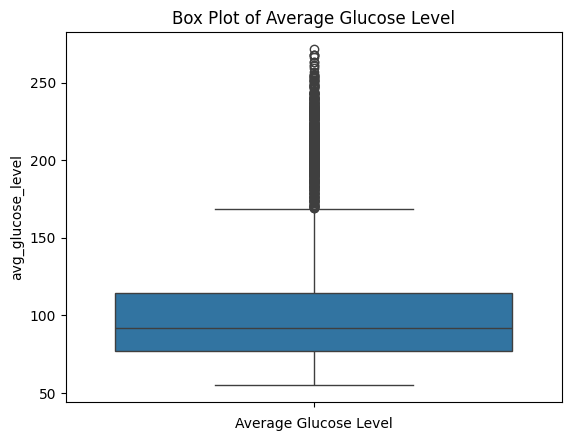

In [34]:
sns.boxplot(data['avg_glucose_level']) # Plot a box plot for average glucose level
plt.title('Box Plot of Average Glucose Level')
plt.xlabel('Average Glucose Level')
plt.show()

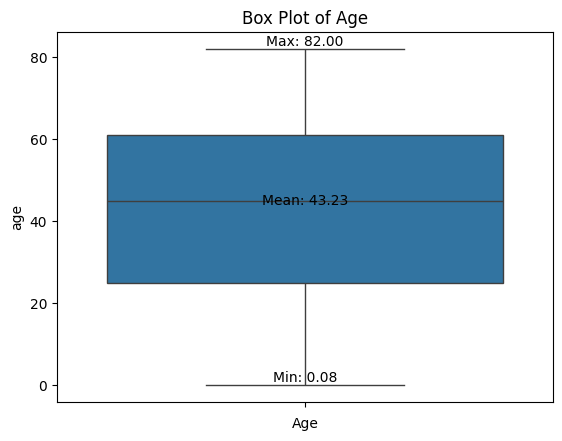

In [35]:
sns.boxplot(data['age']) # Plot a box plot for age

# Add the min, mean and max values to the box plot
plt.text(0, data['age'].min(), f'Min: {data["age"].min():.2f}', ha='center', va='bottom')
plt.text(0, data['age'].mean(), f'Mean: {data["age"].mean():.2f}', ha='center', va='bottom')
plt.text(0, data['age'].max(), f'Max: {data["age"].max():.2f}', ha='center', va='bottom')

plt.title('Box Plot of Age')
plt.xlabel('Age')
plt.show()

##### 2.1.2.5 Violin Plots (Numerical Variables)
**Violin plots** are similar to box plots but also show the density of the data at different values.
<br>They provide a more detailed view of the distribution of numerical variables, allowing us to see where the data is concentrated and how it is spread out.

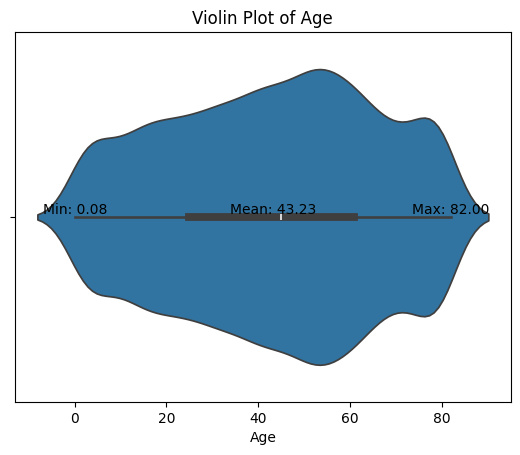

In [36]:
# Violin plot for age
sns.violinplot(x=data['age'])

# Add the min, mean and max values to the violin plot
plt.text(data['age'].min(), 0, f'Min: {data["age"].min():.2f}', ha='center', va='bottom')
plt.text(data['age'].mean(), 0, f'Mean: {data["age"].mean():.2f}', ha='center', va='bottom')
plt.text(data['age'].max(), 0, f'Max: {data["age"].max():.2f}', ha='center', va='bottom')

plt.title('Violin Plot of Age')
plt.xlabel('Age')
plt.show()
